## Outline

This notebook walks through the analysis of 99 customer call transcripts extracted by Voxel's internal pipeline.

1. **Data at a glance** — what's in the dataset
2. **The normalization problem** — why raw label counts are misleading
3. **Trying auto-clustering** — Jaccard similarity, and where it falls short
4. **Keyword-based categories** — a more practical grouping approach
5. **Quality checks** — cross-bucket leakage, speaker attribution, platform features
6. **What changes when you check who's talking** — naive vs. filtered ranking
7. **Opportunity ranking** — non-safety categories scored by breadth, customer voice, and confidence
8. **Observations** — what the data tells us (recommendations are in the memo)

## 1. Data at a glance

99 JSON files from customer call transcripts. Each file contains extracted safety and non-safety use cases with labels, descriptions, and supporting evidence quotes attributed to individual speakers.

In [1]:
from pipeline import load_all, add_voice_mix, cross_bucket_labels, cross_bucket_quotes, flag_platform_items, flag_weak_evidence
from ranking import categorize, rank_nonsafety, map_buyer

df, empty_files = load_all()
print(f"{len(df)} use cases extracted from {df.file_id.nunique()} calls ({len(empty_files)} files had no extractions)")
print(f"  Safety:     {len(df[df.bucket=='safety'])} items")
print(f"  Non-safety: {len(df[df.bucket=='nonsafety'])} items")
print(f"\nDate range: {df.start_time.min().strftime('%B %Y')} to {df.start_time.max().strftime('%B %Y')}")

702 use cases extracted from 92 calls (7 files had no extractions)
  Safety:     471 items
  Non-safety: 231 items

Date range: January 2022 to December 2024


## 2. The normalization problem

The first thing I checked was label reuse. In a well-tuned extraction pipeline, you'd expect a controlled set of labels — maybe 15 or 20 categories. Instead:

In [2]:
for bucket in ["safety", "nonsafety"]:
    subset = df[df.bucket == bucket]
    n, u = len(subset), subset.label.nunique()
    print(f"{bucket:10s}: {u}/{n} labels are unique ({100*u/n:.1f}%)")

safety    : 459/471 labels are unique (97.5%)
nonsafety : 228/231 labels are unique (98.7%)


## 3. Trying auto-clustering

I tried clustering labels by token overlap (Jaccard similarity on lowercased words). The results varied a lot by threshold:

In [3]:
from pipeline import auto_cluster
labels = df.label.unique().tolist()
for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    m = auto_cluster(labels, threshold=t)
    print(f"  threshold={t}: {len(set(m.values()))} clusters from {len(labels)} labels")

# At 0.3, unrelated concepts get merged:
m_loose = auto_cluster(labels, threshold=0.3)
pit_cluster = [l for l, r in m_loose.items() if r == m_loose.get("PIT speeding monitoring", "")]
print(f"\nAt threshold=0.3, the 'PIT speeding' cluster has {len(pit_cluster)} labels including:")
for l in sorted(pit_cluster)[:5]:
    print(f"  - {l}")
print("  ...")
print("That's too loose — PPE and proximity shouldn't be grouped with speeding.")

  threshold=0.3: 285 clusters from 659 labels


  threshold=0.35: 376 clusters from 659 labels


  threshold=0.4: 417 clusters from 659 labels


  threshold=0.45: 476 clusters from 659 labels


  threshold=0.5: 479 clusters from 659 labels



At threshold=0.3, the 'PIT speeding' cluster has 261 labels including:
  - Access heatmaps for improper bend and overreaching
  - Access/egress safety and restricted area intrusion
  - Accountable coaching and training via Actions tied to incident clips
  - Address PIT parking duration impacting aisle flow at central crossway
  - Adjust ergonomics detection for exoskeleton users
  ...
That's too loose — PPE and proximity shouldn't be grouped with speeding.


## 4. Keyword-based categories

Token overlap misses semantic matches and over-merges at lower thresholds. Since workplace safety and operations categories are fairly well-defined, I wrote keyword patterns for the major groups and verified each grouping by hand. This gave me cleaner, auditable clusters.

In [4]:
df = add_voice_mix(df)
df = flag_platform_items(df)
df = flag_weak_evidence(df)
df = categorize(df)

print("=== Safety categories ===")
for cat, grp in df[df.bucket == "safety"].groupby("category"):
    print(f"  {cat:40s} {grp.file_id.nunique():3d} calls")

print("\n=== Non-safety categories ===")
for cat, grp in df[df.bucket == "nonsafety"].groupby("category"):
    print(f"  {cat:40s} {grp.file_id.nunique():3d} calls")

=== Safety categories ===
  Dock & loading safety                      9 calls
  Ergonomics                                53 calls
  Intersection compliance                   18 calls
  Obstruction & housekeeping                25 calls
  Other                                     75 calls
  PIT speeding                              15 calls
  PIT-PIT proximity                         11 calls
  PIT-pedestrian proximity                  29 calls
  PPE compliance                            35 calls
  Restricted zone                           23 calls
  Spill & floor hazard                      20 calls
  Working at heights                        16 calls

=== Non-safety categories ===
  Analytics & reporting                     33 calls
  Coaching & action workflow                20 calls
  Dock & door operations                    12 calls
  Food safety & controlled environment       3 calls
  Incident investigation                     7 calls
  Integration & data export               

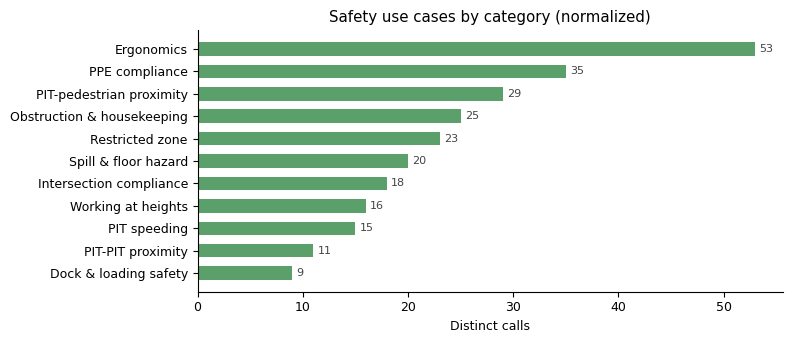

In [5]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 9})

safety = df[df.bucket == "safety"].groupby("category").file_id.nunique().sort_values()
safety_filtered = safety[safety.index != "Other"]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(safety_filtered.index, safety_filtered.values, color="#5b9f6b", height=0.6)
ax.set_xlabel("Distinct calls")
ax.set_title("Safety use cases by category (normalized)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, val in zip(bars, safety_filtered.values):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8, color="#444")
plt.tight_layout()
plt.savefig("outputs/safety_categories.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Quality checks

Three things I wanted to check about this extraction — the kinds of failure modes you'd look for in any classification pipeline:

In [6]:
xb_labels = cross_bucket_labels(df)
xb_quotes = cross_bucket_quotes(df)
ns = df[df.bucket == "nonsafety"]

print("1. Cross-bucket leakage")
print(f"   Exact label overlap: {len(xb_labels)} labels in {xb_labels.file_id.nunique()} files")
print(f"   Evidence quote reuse: {len(xb_quotes)} of {df.file_id.nunique()} files ({100*len(xb_quotes)/df.file_id.nunique():.0f}%)")

print("\n2. Speaker attribution")
voxel_only = ns[ns.customer_quotes == 0]
print(f"   Non-safety items with Voxel-only speakers: {len(voxel_only)}/{len(ns)} ({100*len(voxel_only)/len(ns):.0f}%)")
print(f"   These are things Voxel reps mentioned, not what customers asked for.")

print("\n3. Platform features vs. customer needs")
plat = ns[ns.is_platform_item == True]
print(f"   Flagged as platform description (keyword + Voxel-only): {len(plat)}")
print(f"   Items with platform keywords but customer speakers (kept): {len(ns[ns.label.str.contains('workflow|dashboard|board', case=False, na=False)]) - len(plat)}")

1. Cross-bucket leakage
   Exact label overlap: 28 labels in 24 files
   Evidence quote reuse: 49 of 92 files (53%)

2. Speaker attribution
   Non-safety items with Voxel-only speakers: 74/231 (32%)
   These are things Voxel reps mentioned, not what customers asked for.

3. Platform features vs. customer needs
   Flagged as platform description (keyword + Voxel-only): 10
   Items with platform keywords but customer speakers (kept): 17


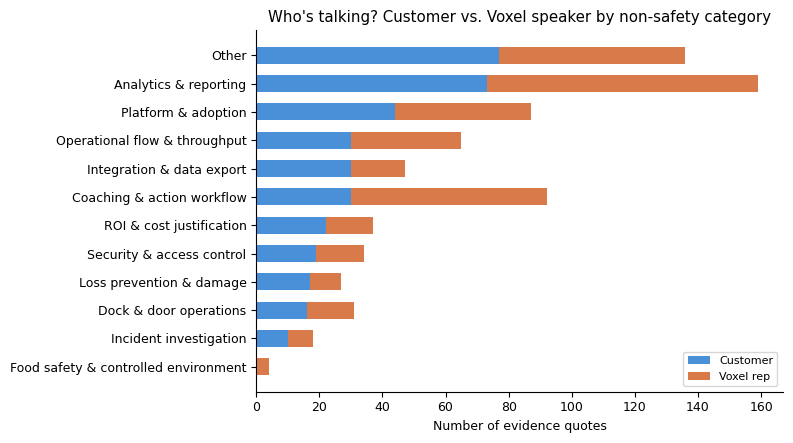

In [7]:
ns_cats = df[df.bucket == "nonsafety"].groupby("category").agg(
    customer=("customer_quotes", "sum"),
    voxel=("voxel_quotes", "sum"),
).sort_values("customer", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
y = range(len(ns_cats))
ax.barh(y, ns_cats["customer"], height=0.6, label="Customer", color="#4a90d9")
ax.barh(y, ns_cats["voxel"], height=0.6, left=ns_cats["customer"], label="Voxel rep", color="#d97a4a")
ax.set_yticks(y)
ax.set_yticklabels(ns_cats.index)
ax.set_xlabel("Number of evidence quotes")
ax.set_title("Who's talking? Customer vs. Voxel speaker by non-safety category")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/speaker_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Rethinking platform features

I initially flagged everything with 'dashboard' or 'workflow' as a platform feature. But some of those are actually customer requests — a customer saying *"can we get a board for X?"* is real demand, not a feature description. So I combined the keyword check with speaker attribution: only flag items where the keyword matches AND all evidence comes from Voxel speakers.

## What changes when you check who's talking

Before filtering by speaker, the top non-safety categories by raw call count are analytics (33), coaching (20), and operational flow (19). But if two-thirds of the coaching evidence comes from Voxel reps demoing existing features, that's not customer demand — it's a pitch artifact. Here's what the naive ranking looks like vs. the customer-voice ratio:

In [8]:
# Naive ranking: pure call count, all categories
naive = ns.groupby("category").agg(
    calls=("file_id", "nunique"),
    cust_quotes=("customer_quotes", "sum"),
    vox_quotes=("voxel_quotes", "sum"),
).reset_index()
naive["customer_voice"] = (naive["cust_quotes"] / (naive["cust_quotes"] + naive["vox_quotes"]).replace(0,1)).round(2)
naive = naive.sort_values("calls", ascending=False)

print("Top 5 by raw call count:")
for _, r in naive.head(5).iterrows():
    flag = " ← mostly Voxel" if r["customer_voice"] < 0.4 else ""
    print(f"  {r['category']:42s} {r['calls']:2d} calls   {r['customer_voice']:.0%} customer voice{flag}")

print("\nCoaching drops from #3 to irrelevant once you see that 67% of its evidence")
print("is Voxel reps walking through the Actions feature. The real opportunities")
print("are further down the raw list.")

Top 5 by raw call count:
  Analytics & reporting                      33 calls   46% customer voice
  Other                                      32 calls   57% customer voice
  Coaching & action workflow                 20 calls   33% customer voice ← mostly Voxel
  Operational flow & throughput              19 calls   46% customer voice
  Platform & adoption                        18 calls   51% customer voice

Coaching drops from #3 to irrelevant once you see that 67% of its evidence
is Voxel reps walking through the Actions feature. The real opportunities
are further down the raw list.


## 6. Opportunity ranking

Ranking by three metrics separately — breadth (distinct calls), customer voice ratio, and average evidence depth — plus a simple confidence label (HIGH if ≥8 calls and ≥50% customer voice, MEDIUM if ≥5 calls, LOW otherwise). With category sizes ranging from 3 to 33 calls, a composite score would be dominated by noise in the smaller groups, so I kept the metrics apart and let the memo weigh them.

In [9]:
ranking = rank_nonsafety(df)
ranking["buyer"] = ranking["category"].map(map_buyer)
# Focus on categories that represent actual use cases, not platform features
recommend = ranking[~ranking.category.isin([
    "Other", "Analytics & reporting", "Coaching & action workflow",
    "Platform & adoption", "Food safety & controlled environment"
])]
print(recommend.to_string(index=False))

                     category  distinct_calls  total_rows  customer_voice_ratio  avg_evidence confidence                   buyer
Operational flow & throughput              19          23                  0.46           2.8     MEDIUM              Operations
       Dock & door operations              12          14                  0.52           2.2       HIGH Facilities / Operations
    Integration & data export              12          14                  0.64           3.4       HIGH          IT / Analytics
    Security & access control              11          13                  0.56           2.6       HIGH   Facilities / Security
     Loss prevention & damage              10          10                  0.63           2.7       HIGH            LP / Finance
     ROI & cost justification               9          11                  0.59           3.4       HIGH           Finance / EHS
       Incident investigation               7           7                  0.56           2.6    

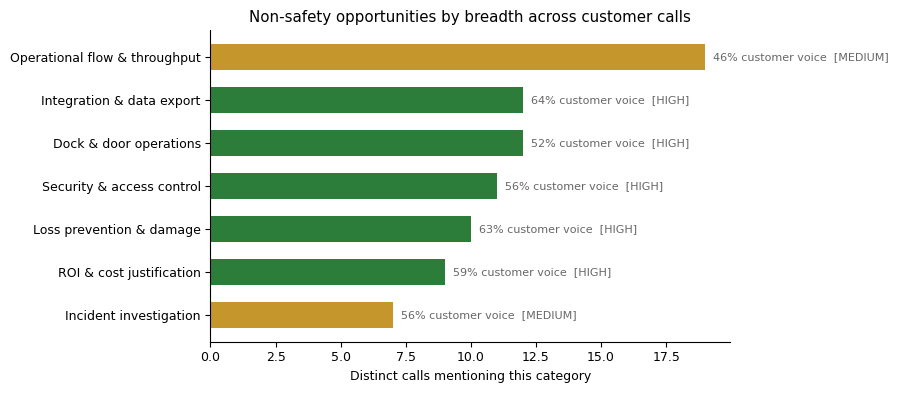

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
data = recommend.sort_values("distinct_calls")
colors = {"HIGH": "#2d7d3a", "MEDIUM": "#c4962c", "LOW": "#b04040"}
bar_colors = [colors.get(c, "#999") for c in data["confidence"]]
bars = ax.barh(data["category"], data["distinct_calls"], color=bar_colors, height=0.6)
ax.set_xlabel("Distinct calls mentioning this category")
ax.set_title("Non-safety opportunities by breadth across customer calls")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, (_, row) in zip(bars, data.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['customer_voice_ratio']:.0%} customer voice  [{row['confidence']}]",
            va="center", fontsize=8, color="#666")

plt.tight_layout()
plt.savefig("outputs/nonsafety_opportunities.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Save outputs
ns = df[df.bucket == "nonsafety"]

# Normalized view (full dataset)
view = df[["file_id", "company", "start_time", "bucket", "category", "label",
           "description", "evidence_count", "customer_quotes", "voxel_quotes",
           "voice_ratio", "is_platform_item", "weak_evidence"]].copy()
view.to_csv("outputs/normalized_view.csv", index=False)

# Ranking with confidence
ranking.to_csv("outputs/ranking_summary.csv", index=False)

# Quality audit detail: cross-bucket overlap
xb_detail = xb_labels.merge(
    df[["file_id", "label", "bucket", "company", "description"]].drop_duplicates(),
    on=["file_id", "label"])
xb_detail.to_csv("outputs/cross_bucket_overlap.csv", index=False)

# Quality audit detail: Voxel-only non-safety items
voxel_items = ns[ns.customer_quotes == 0][
    ["file_id", "company", "category", "label", "description", "voxel_quotes"]]
voxel_items.to_csv("outputs/voxel_only_items.csv", index=False)

print(f"Exported: normalized_view ({len(view)} rows), ranking_summary ({len(ranking)} rows)")
print(f"          cross_bucket_overlap ({len(xb_detail)} rows), voxel_only_items ({len(voxel_items)} rows)")

Exported: normalized_view (702 rows), ranking_summary (12 rows)
          cross_bucket_overlap (56 rows), voxel_only_items (74 rows)


## 7. Observations

- Operational flow and dock/door categories show the broadest interest, with moderate customer voice.
- Loss prevention mentions are less frequent but have the highest customer voice ratio among specific categories — customers bring it up, Voxel doesn't have to pitch it.
- Food safety appeared in only 3 calls and was mentioned exclusively by Voxel reps — not a demand signal.
- Coaching and action workflow had the lowest customer voice (33%) — almost entirely Voxel demoing existing features.
- About a third of non-safety items come from Voxel speakers only, which means the extraction overstates actual customer interest.

Recommendations and quality assessment are in the memo.